In [9]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor

In [65]:
df=pd.read_csv(r"C:\Users\EXIRIM_Compurer's\Desktop\python\cars.csv")
pd.set_option('display.max_columns', None)
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,NaN,507687355.0,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,NaN,Lada Azərbaycan,554092445.0,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,NaN,502126242.0,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.0,AZN,Babək,NaN,774999004.0,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyo

In [66]:
df.columns

Index(['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x',
       'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes',
       'production_year', 'engine_displacement_num',
       'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit',
       'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url',
       'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description',
       'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated',
       'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili',
       'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı',
       'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni',
       'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y',
       'car_rel_url', 'extra_info'],
      dtype='object')

In [67]:
df.drop(columns=[
    'id_y',
    'id_x',
    'price_y',
    'currency_y',
    'car_rel_url_y',
    'car_rel_url_x',
    'car_details_id_y',
    'name',
    'datetime_scrape',
    'datetime_product',
    'day',
    'hour',
    'cars_id',
    'datetime',
    'description',
    'updated',
    'views', 
    'car_details_id_x',
    'Şəhər', 
    'name'
], inplace=True)


In [68]:
df.drop(columns=[
    'img_url',
    'phone',
    'owner_name',
    'shop_name',
    'extra_info'
], inplace=True)


In [69]:
df.shape

(653721, 32)

In [70]:
df.head()

,price_x,currency_x,city,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,vin,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,car_rel_url
0,15000.0,AZN,bakı,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,/autos/8748840-hyundai-i30
1,23700.0,AZN,bakı,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,NaN,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,/autos/8475807-lada-vaz-niva-travel
2,35600.0,$,bakı,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,NaN,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,/autos/8739686-toyota-land-cruiser
3,26700.0,AZN,bakı,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,5NPD84LFXKH406133,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,/autos/8712597-hyundai-elantra
4,10500.0,AZN,bakı,"2007, 1.5 L, 354 000 km",2007,1.5,L,354000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,NaN,Liftbek,2007,Amerika,Toyota,Prius,1.5 L/76 a.g./Hibrid,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,/autos/8674773-toyota-prius


In [71]:
df['currency_x'].unique()

array(['AZN', '$', '€'], dtype=object)

In [72]:
rates = {
    'AZN': 1,
    '$': 1.7,
    '€': 1.85
}


In [73]:
df['price_azn'] = df['price_x'] * df['currency_x'].map(rates)
df.drop(columns=['price_x', 'currency_x'], inplace=True)


In [74]:
df.head()

,city,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,vin,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,car_rel_url,price_azn
0,bakı,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,/autos/8748840-hyundai-i30,15000.0
1,bakı,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,NaN,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,/autos/8475807-lada-vaz-niva-travel,23700.0
2,bakı,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,NaN,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,/autos/8739686-toyota-land-cruiser,60520.0
3,bakı,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,5NPD84LFXKH406133,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,/autos/8712597-hyundai-elantra,26700.0
4,bakı,"2007, 1.5 L, 354 000 km",2007,1.5,L,354000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,NaN,Liftbek,2007,Amerika,Toyota,Prius,1.5 L/76 a.g./Hibrid,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,/autos/8674773-toyota-prius,10500.0


In [75]:
df['city'].nunique()

75

In [76]:
df=df.drop('city',axis=1)

In [77]:
df=df.drop('attributes',axis=1)

In [78]:
df['engine_displacement_unit'].nunique()

1

In [79]:
df['kilometrage_unit'].nunique()

1

In [80]:
df=df.drop(['engine_displacement_unit','kilometrage_unit'],axis=1)

In [81]:
df=df.drop('vin',axis=1)

In [82]:
df['Ban növü'].nunique()

36

In [83]:
df=df.drop('Buraxılış ili',axis=1)

In [84]:
df['Hansı bazar üçün yığılıb'].nunique()

9

In [85]:
df['Mühərrik'].nunique()

7410

In [86]:
df['Ban növü'].value_counts().head(20)


Ban növü
Sedan                      277955
Offroader / SUV, 5 qapı    225026
Hetçbek, 5 qapı             43094
Liftbek                     22629
Universal, 5 qapı           18337
Furqon                      16803
Minivan                     10056
Yük maşını                   7835
Offroader / SUV, 3 qapı      6402
Pikap, ikiqat kabin          4785
SUV Kupe                     4451
Kupe                         3743
Kompakt-Van                  3437
Dartqı                       2599
Motosiklet                   1914
Mikroavtobus                 1418
Hetçbek, 3 qapı               985
Kabriolet                     533
Hetçbek, 4 qapı               436
Avtobus                       312
Name: count, dtype: int64

In [87]:
df['Ban növü'] = df['Ban növü'].str.split(',').str[0].str.strip()


In [88]:
main_types = [
    'Sedan',
    'Offroader / SUV',
    'Hetçbek',
    'Universal',
    'Minivan',
    'Pikap',
    'Kupe'
]

df['Ban növü'] = df['Ban növü'].apply(
    lambda x: x if x in main_types else 'Other'
)


In [89]:
df['Ban növü'].unique()

array(['Hetçbek', 'Offroader / SUV', 'Sedan', 'Other', 'Minivan',
       'Universal', 'Kupe', 'Pikap'], dtype=object)

In [90]:
engine_split = df['Mühərrik'].str.split('/', expand=True)

df['horse_power'] = (
    engine_split[1]
    .str.extract(r'(\d+)')[0]
    .astype(float)
)


df['engine_volume'] = (
    engine_split[0]
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

df['fuel_type'] = engine_split[2].str.strip()



In [91]:
df.head()

,production_year,engine_displacement_num,kilometrage_num,barter,loan,salon,spare_parts,vip,featured,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,car_rel_url,price_azn,horse_power,engine_volume,fuel_type
0,2008,1.6,270000,NaN,NaN,NaN,NaN,NaN,NaN,Hetçbek,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,/autos/8748840-hyundai-i30,15000.0,115.0,1.6,Dizel
1,2024,1.7,0,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,/autos/8475807-lada-vaz-niva-travel,23700.0,80.0,1.7,Benzin
2,2011,4.0,164750,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,Offroader / SUV,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,/autos/8739686-toyota-land-cruiser,60520.0,282.0,4.0,Benzin
3,2018,2.0,126000,NaN,NaN,NaN,NaN,vipped-icon,NaN,Sedan,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,/autos/8712597-hyundai-elantra,26700.0,150.0,2.0,Benzin
4,2007,1.5,354000,NaN,NaN,NaN,NaN,vipped-icon,NaN,Other,Amerika,Toyota,Prius,1.5 L/76 a.g./Hibrid,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,/autos/8674773-toyota-prius,10500.0,76.0,1.5,Hibrid


In [92]:
df['vip'].nunique()

1

In [93]:
df['featured'].nunique()

1

In [94]:
df=df.drop(['vip','featured','Mühərrik','car_rel_url'],axis=1)

In [95]:
df.shape

(653721, 24)

In [96]:
df=df.drop('engine_displacement_num',axis=1)

In [97]:
df['Vəziyyəti'].nunique()

4

In [98]:
df.head()

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type
0,2008,270000,NaN,NaN,NaN,NaN,Hetçbek,NaN,Hyundai,i30,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,15000.0,115.0,1.6,Dizel
1,2024,0,NaN,NaN,Salon,NaN,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva Travel,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,23700.0,80.0,1.7,Benzin
2,2011,164750,NaN,NaN,NaN,NaN,Offroader / SUV,Rəsmi diler,Toyota,Land Cruiser,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,60520.0,282.0,4.0,Benzin
3,2018,126000,NaN,NaN,NaN,NaN,Sedan,NaN,Hyundai,Elantra,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,26700.0,150.0,2.0,Benzin
4,2007,354000,NaN,NaN,NaN,NaN,Other,Amerika,Toyota,Prius,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,10500.0,76.0,1.5,Hibrid


In [99]:
df['barter'].nunique()

1

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   production_year           653721 non-null  int64  
 1   kilometrage_num           653721 non-null  int64  
 2   barter                    225553 non-null  object 
 3   loan                      163340 non-null  object 
 4   salon                     193339 non-null  object 
 5   spare_parts               1762 non-null    object 
 6   Ban növü                  653721 non-null  object 
 7   Hansı bazar üçün yığılıb  464216 non-null  object 
 8   Marka                     653721 non-null  object 
 9   Model                     653720 non-null  object 
 10  Qəzalı                    1761 non-null    object 
 11  Rəng                      653721 non-null  object 
 12  Sahiblər                  432100 non-null  object 
 13  Sürətlər qutusu           653721 non-null  o

In [101]:
df['barter']=df['barter'].fillna('Yoxdur')

In [102]:
df['loan'].nunique()

1

In [103]:
df['loan']=df['loan'].fillna('Yoxdur')

In [104]:
df[df['loan'].notnull()]

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type
0,2008,270000,Yoxdur,Yoxdur,NaN,NaN,Hetçbek,NaN,Hyundai,i30,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,15000.0,115.0,1.6,Dizel
1,2024,0,Yoxdur,Yoxdur,Salon,NaN,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva Travel,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,23700.0,80.0,1.7,Benzin
2,2011,164750,Yoxdur,Yoxdur,NaN,NaN,Offroader / SUV,Rəsmi diler,Toyota,Land Cruiser,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,60520.0,282.0,4.0,Benzin
3,2018,126000,Yoxdur,Yoxdur,NaN,NaN,Sedan,NaN,Hyundai,Elantra,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,26700.0,150.0,2.0,Benzin
4,2007,354000,Yoxdur,Yoxdur,NaN,NaN,Other,Amerika,Toyota,Prius,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,10500.0,76.0,1.5,Hibrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653716,2008,320000,Barter mümkündür,Yoxdur,NaN,NaN,Other,NaN,Toyota,Prius,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,320 000 km,Ön,10800.0,76.0,1.5,Hibrid
653717,2011,155000,Yoxdur,Yoxdur,NaN,NaN,Offroader / SUV,NaN,UAZ,Hunter,NaN,Boz,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,155 000 km,Tam,9500.0,135.0,2.9,Benzin
653718,2018,77926,Yoxdur,Yoxdur,NaN,NaN,Sedan,NaN,Hyundai,Elantra,NaN,Göy,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,77 926 km,Ön,25400.0,150.0,2.0,Benzin
653719,1999,250000,Barter mümkündür,Yoxdur,NaN,NaN,Offroader / SUV,Amerika,Jeep,Grand Cherokee,NaN,Qara,2,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,250 000 km,Tam,10600.0,258.0,4.7,Benzin


In [105]:
df['salon'].nunique()

1

In [106]:
df[df['salon'].notnull()]

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type
1,2024,0,Yoxdur,Yoxdur,Salon,NaN,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva Travel,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,23700.0,80.0,1.7,Benzin
52,2023,0,Yoxdur,Yoxdur,Salon,NaN,Other,Avropa,C.Moto,CM250R-HY,NaN,Yaş Asfalt,1,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,NaN,0 km,Arxa,6200.0,35.0,0.3,Benzin
53,2023,0,Yoxdur,Yoxdur,Salon,NaN,Other,Avropa,C.Moto,CM400R-18,NaN,Yaş Asfalt,1,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,NaN,0 km,Arxa,8300.0,45.0,0.4,Benzin
55,2023,0,Yoxdur,Yoxdur,Salon,NaN,Offroader / SUV,Avropa,Toyota,Highlander,NaN,Boz,NaN,Avtomat,"Vuruğu yoxdur, rənglənməyib",Bəli,NaN,0 km,Tam,84830.0,265.0,2.4,Benzin
88,2024,0,Yoxdur,Yoxdur,Salon,NaN,Sedan,Rəsmi diler,BMW,750e xDrive,NaN,Qara,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,333000.0,489.0,3.0,Plug-in Hibrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653664,0,0,Yoxdur,Yoxdur,Salon,NaN,Other,NaN,ZEEKR,001,NaN,Göy,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,76500.0,NaN,544.0,None
653693,2023,12500,Barter mümkündür,Yoxdur,Salon,NaN,Offroader / SUV,Rəsmi diler,BMW,XM,NaN,Qara,NaN,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,12 500 km,Tam,348500.0,653.0,4.4,Plug-in Hibrid
653695,2021,39500,Barter mümkündür,Yoxdur,Salon,NaN,Offroader / SUV,Rəsmi diler,BMW,X7,NaN,Boz,NaN,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,39 500 km,Tam,161500.0,340.0,3.0,Benzin
653708,2003,285000,Barter mümkündür,Kreditdədir,Salon,NaN,Offroader / SUV,NaN,Toyota,Land Cruiser Prado,NaN,Gümüşü,NaN,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,285 000 km,Tam,22900.0,163.0,2.7,Benzin


In [107]:
df['salon']=df['salon'].fillna('Yox')

In [108]:
df[df['spare_parts'].notnull()]

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type
79,2014,221406,Yoxdur,Yoxdur,Yox,Qəzalı,Offroader / SUV,Avropa,Kia,Sorento,Bəli,Ağ,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,7,221 406 km,Tam,35500.0,184.0,2.0,Dizel
1446,2010,222734,Yoxdur,Yoxdur,Yox,Qəzalı,Sedan,Avropa,Kia,Cerato,Bəli,Qara,2,Avtomat,"Vuruğu var, rənglənməyib",Xeyr,5,222 734 km,Ön,12700.0,124.0,1.6,Benzin
1713,2007,370000,Barter mümkündür,Kreditdədir,Yox,Qəzalı,Other,Avropa,Mercedes,Atego 816,Bəli,Ağ,2,Mexaniki,"Vuruğu var, rənglənməyib",Xeyr,3,370 000 km,Arxa,15000.0,156.0,4.3,Dizel
1750,2005,300000,Yoxdur,Yoxdur,Yox,Qəzalı,Sedan,Rusiya,ZAZ,Slavuta,Bəli,Ağ,NaN,Mexaniki,"Vuruğu var, rənglənməyib",Xeyr,NaN,300 000 km,Tam,1000.0,43.0,1.2,Benzin
1752,1997,255555,Yoxdur,Yoxdur,Yox,Qəzalı,Sedan,NaN,Mercedes,C 230,Bəli,Qara,0,Avtomat,"Vuruğu var, rənglənməyib",Xeyr,NaN,255 555 km,Arxa,6800.0,230.0,2.3,Benzin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651946,1995,358000,Barter mümkündür,Yoxdur,Yox,Qəzalı,Sedan,Avropa,Mercedes,C 200,Bəli,Açıq yaşıl,4 və daha çox,Avtomat,"Vuruğu var, rənglənməyib",Xeyr,5,358 000 km,Arxa,5900.0,136.0,2.0,Benzin
652747,2024,13000,Yoxdur,Kreditdədir,Yox,Qəzalı,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva,Bəli,Yaşıl,1,Mexaniki,"Vuruğu var, rənglənməyib",Xeyr,5,13 000 km,Tam,16500.0,80.0,1.7,Benzin
652768,2007,232512,Yoxdur,Yoxdur,Yox,Qəzalı,Offroader / SUV,Digər,Mitsubishi,Pajero,Bəli,Ağ,0,Avtomat,"Vuruğu var, rənglənib",Xeyr,7,232 512 km,Tam,13200.0,188.0,3.0,Benzin
653566,2008,312000,Barter mümkündür,Yoxdur,Yox,Qəzalı,Sedan,Rəsmi diler,Kia,Optima,Bəli,Ağ,3,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,312 000 km,Ön,10350.0,190.0,2.7,Benzin


In [109]:
df['spare_parts'].nunique()

1

In [114]:
df['spare_parts']=df['spare_parts'].fillna('Yox')

In [115]:
df.isnull().sum()

production_year                  0
kilometrage_num                  0
barter                           0
loan                             0
salon                            0
spare_parts                      0
Ban növü                         0
Hansı bazar üçün yığılıb    189505
Marka                            0
Model                            1
Qəzalı                      651960
Rəng                             0
Sahiblər                    221621
Sürətlər qutusu                  0
Vəziyyəti                        3
Yeni                             0
Yerlərin sayı               165831
Yürüş                            0
Ötürücü                          0
price_azn                        0
horse_power                   5788
engine_volume                    0
fuel_type                     5788
dtype: int64

In [116]:
df['Hansı bazar üçün yığılıb'].nunique()

9

In [117]:
df['Hansı bazar üçün yığılıb']=df['Hansı bazar üçün yığılıb'].fillna('Yoxdur')

In [120]:
df=df.dropna(subset='Model')

In [121]:
df['Qəzalı']=df['Qəzalı'].fillna('Yoxdur')

C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\3257165792.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Qəzalı']=df['Qəzalı'].fillna('Yoxdur')


In [122]:
df['Qəzalı'].nunique()

2

In [123]:
df['Sahiblər'].nunique()

5

In [125]:
df['Sahiblər']=df['Sahiblər'].fillna(0)

C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\3773192582.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sahiblər']=df['Sahiblər'].fillna(0)


In [126]:
df=df.dropna(subset='Vəziyyəti')

In [127]:
df['Yerlərin sayı'].nunique()

8

In [129]:
mode_by_body = df.groupby('Ban növü')['Yerlərin sayı'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None)


In [130]:
df['Yerlərin sayı'] = df['Yerlərin sayı'].fillna(df['Ban növü'].map(mode_by_body))


C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\1682186389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Yerlərin sayı'] = df['Yerlərin sayı'].fillna(df['Ban növü'].map(mode_by_body))


In [133]:
mode_map = (df.groupby('Model')['fuel_type']
              .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None))

df['fuel_type'] = df['fuel_type'].fillna(df['Model'].map(mode_map))


C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\722773792.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fuel_type'] = df['fuel_type'].fillna(df['Model'].map(mode_map))


In [135]:
hp_map = df.groupby('Model')['horse_power'].median()

df['horse_power'] = df['horse_power'].fillna(
    df['Model'].map(hp_map)
)


C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\1003693468.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horse_power'] = df['horse_power'].fillna(


In [136]:
df.isnull().sum()

production_year               0
kilometrage_num               0
barter                        0
loan                          0
salon                         0
spare_parts                   0
Ban növü                      0
Hansı bazar üçün yığılıb      0
Marka                         0
Model                         0
Qəzalı                        0
Rəng                          0
Sahiblər                      0
Sürətlər qutusu               0
Vəziyyəti                     0
Yeni                          0
Yerlərin sayı                 0
Yürüş                         0
Ötürücü                       0
price_azn                     0
horse_power                 107
engine_volume                 0
fuel_type                   107
dtype: int64

In [137]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode().iloc[0])


C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\2237398395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode().iloc[0])


In [139]:
df['horse_power'] = df['horse_power'].fillna(
    df['horse_power'].median()
)


C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_12376\1608549239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horse_power'] = df['horse_power'].fillna(


In [140]:
df.isnull().sum()

production_year             0
kilometrage_num             0
barter                      0
loan                        0
salon                       0
spare_parts                 0
Ban növü                    0
Hansı bazar üçün yığılıb    0
Marka                       0
Model                       0
Qəzalı                      0
Rəng                        0
Sahiblər                    0
Sürətlər qutusu             0
Vəziyyəti                   0
Yeni                        0
Yerlərin sayı               0
Yürüş                       0
Ötürücü                     0
price_azn                   0
horse_power                 0
engine_volume               0
fuel_type                   0
dtype: int64

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 653717 entries, 0 to 653720
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   production_year           653717 non-null  int64  
 1   kilometrage_num           653717 non-null  int64  
 2   barter                    653717 non-null  object 
 3   loan                      653717 non-null  object 
 4   salon                     653717 non-null  object 
 5   spare_parts               653717 non-null  object 
 6   Ban növü                  653717 non-null  object 
 7   Hansı bazar üçün yığılıb  653717 non-null  object 
 8   Marka                     653717 non-null  object 
 9   Model                     653717 non-null  object 
 10  Qəzalı                    653717 non-null  object 
 11  Rəng                      653717 non-null  object 
 12  Sahiblər                  653717 non-null  object 
 13  Sürətlər qutusu           653717 non-null  object

In [142]:
df['Rəng'].nunique()

18

In [143]:
num_cols=df.select_dtypes(exclude='object')
cat_cols=df.select_dtypes(include='object')

In [144]:
num_cols

,production_year,kilometrage_num,price_azn,horse_power,engine_volume
0,2008,270000,15000.0,115.0,1.6
1,2024,0,23700.0,80.0,1.7
2,2011,164750,60520.0,282.0,4.0
3,2018,126000,26700.0,150.0,2.0
4,2007,354000,10500.0,76.0,1.5
...,...,...,...,...,...
653716,2008,320000,10800.0,76.0,1.5
653717,2011,155000,9500.0,135.0,2.9
653718,2018,77926,25400.0,150.0,2.0
653719,1999,250000,10600.0,258.0,4.7


In [145]:
cat_cols

,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,fuel_type
0,Yoxdur,Yoxdur,Yox,Yox,Hetçbek,Yoxdur,Hyundai,i30,Yoxdur,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Dizel
1,Yoxdur,Yoxdur,Salon,Yox,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva Travel,Yoxdur,Yaşıl,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Benzin
2,Yoxdur,Yoxdur,Yox,Yox,Offroader / SUV,Rəsmi diler,Toyota,Land Cruiser,Yoxdur,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Benzin
3,Yoxdur,Yoxdur,Yox,Yox,Sedan,Yoxdur,Hyundai,Elantra,Yoxdur,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,126 000 km,Ön,Benzin
4,Yoxdur,Yoxdur,Yox,Yox,Other,Amerika,Toyota,Prius,Yoxdur,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,Hibrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653716,Barter mümkündür,Yoxdur,Yox,Yox,Other,Yoxdur,Toyota,Prius,Yoxdur,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,320 000 km,Ön,Hibrid
653717,Yoxdur,Yoxdur,Yox,Yox,Offroader / SUV,Yoxdur,UAZ,Hunter,Yoxdur,Boz,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,155 000 km,Tam,Benzin
653718,Yoxdur,Yoxdur,Yox,Yox,Sedan,Yoxdur,Hyundai,Elantra,Yoxdur,Göy,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,77 926 km,Ön,Benzin
653719,Barter mümkündür,Yoxdur,Yox,Yox,Offroader / SUV,Amerika,Jeep,Grand Cherokee,Yoxdur,Qara,2,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,250 000 km,Tam,Benzin


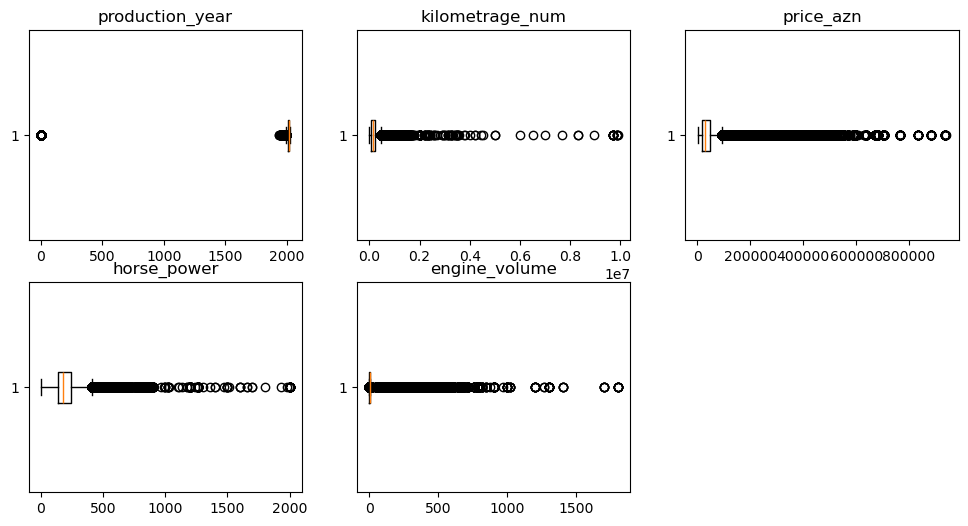

In [154]:
plt.figure(figsize=(12,6))
for i,col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    plt.boxplot(df[col],vert=False) 
    plt.title(col)

plt.show()

In [155]:
df[df['production_year']==0]

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type
434384,0,0,Barter mümkündür,Kreditdədir,Salon,Yox,Offroader / SUV,Rəsmi diler,Chery,eQ7,Yoxdur,Qara,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Arxa,54900.0,211.0,211.0,Elektro
434385,0,0,Barter mümkündür,Kreditdədir,Salon,Yox,Offroader / SUV,Rəsmi diler,Chery,eQ7,Yoxdur,Ağ,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Arxa,54900.0,211.0,211.0,Elektro
434386,0,0,Barter mümkündür,Kreditdədir,Salon,Yox,Offroader / SUV,Rəsmi diler,Chery,eQ7,Yoxdur,Mavi,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Arxa,54900.0,211.0,211.0,Elektro
434387,0,0,Barter mümkündür,Kreditdədir,Salon,Yox,Offroader / SUV,Rəsmi diler,Chery,eQ7,Yoxdur,Boz,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Arxa,54900.0,211.0,211.0,Elektro
434572,0,0,Yoxdur,Yoxdur,Yox,Yox,Offroader / SUV,Çin,Volkswagen,ID.4 Crozz,Yoxdur,Ağ,1,Reduktor,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,13 500 km,Tam,49130.0,204.0,313.0,Elektro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653355,0,0,Yoxdur,Yoxdur,Yox,Yox,Other,Avropa,Tufan,M50,Yoxdur,Qırmızı,1,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,2,18 000 km,Arxa,650.0,6.0,50.0,Benzin
653411,0,0,Yoxdur,Yoxdur,Yox,Yox,Offroader / SUV,Amerika,Kia,EV6,Yoxdur,Göy,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Xeyr,4,16 000 km,Tam,72420.0,320.0,580.0,Elektro
653485,0,0,Yoxdur,Yoxdur,Yox,Yox,Offroader / SUV,Avropa,BYD,Yuan Plus,Yoxdur,Yaş Asfalt,0,Reduktor,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Ön,38900.0,204.0,204.0,Elektro
653604,0,0,Yoxdur,Yoxdur,Yox,Yox,Other,Avropa,Vespa,Sprint 150,Yoxdur,Qırmızı,2,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,2,13 000 km,Arxa,3000.0,20.0,150.0,Benzin


In [156]:
df.shape

(653717, 23)

In [159]:
df = df[df['production_year'] != 0]


In [160]:
df[df['price_azn']==0]

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type


In [161]:
df.head()

,production_year,kilometrage_num,barter,loan,salon,spare_parts,Ban növü,Hansı bazar üçün yığılıb,Marka,Model,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,price_azn,horse_power,engine_volume,fuel_type
0,2008,270000,Yoxdur,Yoxdur,Yox,Yox,Hetçbek,Yoxdur,Hyundai,i30,Yoxdur,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,15000.0,115.0,1.6,Dizel
1,2024,0,Yoxdur,Yoxdur,Salon,Yox,Offroader / SUV,Rəsmi diler,LADA (VAZ),Niva Travel,Yoxdur,Yaşıl,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,23700.0,80.0,1.7,Benzin
2,2011,164750,Yoxdur,Yoxdur,Yox,Yox,Offroader / SUV,Rəsmi diler,Toyota,Land Cruiser,Yoxdur,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,60520.0,282.0,4.0,Benzin
3,2018,126000,Yoxdur,Yoxdur,Yox,Yox,Sedan,Yoxdur,Hyundai,Elantra,Yoxdur,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,126 000 km,Ön,26700.0,150.0,2.0,Benzin
4,2007,354000,Yoxdur,Yoxdur,Yox,Yox,Other,Amerika,Toyota,Prius,Yoxdur,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,10500.0,76.0,1.5,Hibrid


In [80]:
df.corr(numeric_only=True)

,production_year,kilometrage_num,price_azn,horse_power,engine_volume
production_year,1.000000,-0.627829,0.429628,0.292700,-0.133633
kilometrage_num,-0.627829,1.000000,-0.328188,-0.171258,0.272141
price_azn,0.429628,-0.328188,1.000000,0.639431,0.250007
horse_power,0.292700,-0.171258,0.639431,1.000000,0.455932
engine_volume,-0.133633,0.272141,0.250007,0.455932,1.000000


In [82]:
df=df.drop('production_year',axis=1)

In [93]:
cat_col=[col for col in df.columns if df[col].dtypes == 'object']
num_col=[col for col in df.columns if df[col].dtypes != 'object']

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [91]:
X=df.drop('price_azn',axis=1)
y=df['price_azn']

In [92]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [98]:
num_col.remove('price_azn')

In [89]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 7.0 MB/s eta 0:00:15
   - -------------------------------------- 2.9/101.7 MB 8.9 MB/s eta 0:00:12
   -- ------------------------------------- 5.8/101.7 MB 8.8 MB/s eta 0:00:11
   --- ------------------------------------ 8.1/101.7 MB 9.5 MB/s eta 0:00:10
   ---- ----------------------------------- 10.7/101.7 MB 9.9 MB/s eta 0:00:10
   ---- ----------------------------------- 12.6/101.7 MB 9.7 MB/s eta 0:00:10
   ----- ---------------------------------- 13.6/101.7 MB 9.4 MB/s eta 0:00:10
   ------ --------------------------------- 16.0/101.7 MB 9.4 MB/s eta 0:00:10
   ------- -------------------------------- 18.1/101.7 MB 9.6 MB/s eta 0:00:09
   ------- -------------------------------- 19.7/101.7 MB 9.4 MB/s eta 0:00:09
   -------- ------------------------------- 21.2/101.7 MB 9.1 MB/s eta 0

In [95]:
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder

In [101]:
X_train[cat_col] = X_train[cat_col].astype(str)
X_test[cat_col]  = X_test[cat_col].astype(str)


In [102]:
num_pip=Pipeline([
    ('std',StandardScaler())
])

cat_pip=Pipeline([
    ('ohc',OneHotEncoder(handle_unknown="ignore"))
])

prepro=ColumnTransformer([
    ('num',num_pip,num_col),
    ('cat',cat_pip,cat_col)
])

model=XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

pipeline_xg=Pipeline([
    ('preprocessing',prepro),
    ('model',model)
])

pipeline_xg.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('std',
                                                                   StandardScaler())]),
                                                  ['kilometrage_num',
                                                   'horse_power',
                                                   'engine_volume']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohc',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['barter', 'loan', 'salon',
                                                   'spare_parts', 'Ban növü',
                                                   'Hansı bazar üçün yığılıb',
                                                   'Marka', 'Model', 'Qəzalı',
                                                   'Rəng', 'Sahibl...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [103]:
y_pred=pipeline_xg.predict(X_test)

In [107]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [108]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("R2:",r2_score(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)**0.5)


MAE: 6134.573314051445
MSE: 99106072.4720352
R2: 0.9594347922842569
RMSE: 9955.203286323951


In [110]:
y_tr=pipeline_xg.predict(X_train)
print("TR R2:",r2_score(y_train,y_tr))
y_tst=pipeline_xg.predict(X_test)
print("TST R2:",r2_score(y_test,y_tst))

TR R2: 0.9616605676791142
TST R2: 0.9594347922842569
